# Unit11 Example 03 - CSTR 反應器濃度振盪之頻譜分析 (Limit Cycle Detection)

本 Notebook 使用 `scipy.integrate.solve_ivp()` 模擬非恆溫 CSTR 的非線性動態 (延伸自 Unit09 Example 01)，並以 `scipy.fft` 對模擬時間序列進行頻譜分析，識別極限環振盪週期，比較不同冷卻水溫度下的動態特性。

## 學習目標
- 以 `solve_ivp()` 模擬含 Hopf 分岔行為的非線性 CSTR 動態
- 理解去均值前處理與 Hann 視窗在 ODE 模擬訊號頻譜分析中的重要性
- 使用 `scipy.fft.rfft()` 識別極限環振盪頻率 $f_0$ 與諧波 $2f_0$ 、 $3f_0$
- 比較穩態收斂、週期振盪、較快振盪三類動態的頻譜特徵
- 以 `scipy.fft` 計算自相關函數，交叉驗證振盪週期估計
- 繪製相平面圖、時域曲線、頻譜圖與自相關函數的綜合摘要圖

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit11_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit11'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit11
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Example_03\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.integrate import solve_ivp
from scipy import fft

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.8,
    'axes.unicode_minus': False,
})

import scipy
import matplotlib
print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. CSTR 模型定義與 ODE 模擬

本節定義非恆溫 CSTR 無因次動態方程式（延伸自 Unit09 Example 01），並以 `scipy.integrate.solve_ivp()` 模擬三個不同冷卻水溫度 $T_c$ 條件下的動態行為：
- **Case 1 (Tc = -0.6)**：強冷卻 → 穩態收斂（Stable Steady State）
- **Case 2 (Tc = -0.3)**：中度冷卻 → 極限環振盪（Limit Cycle）
- **Case 3 (Tc = 0.0)**：弱冷卻 → 較快振盪（Fast Oscillation）

**動態方程式：**

$$
\frac{dx_1}{dt} = -x_1 + Da\,(1-x_1)\,\exp\!\left(\frac{x_2}{1+x_2/\varphi}\right)
$$

$$
\frac{dx_2}{dt} = -(1+\kappa)\,x_2 + B\,Da\,(1-x_1)\,\exp\!\left(\frac{x_2}{1+x_2/\varphi}\right) + \kappa\,T_c
$$

**參數：** $Da = 0.15$ ， $B = 14.0$ ， $\varphi = 20.0$ ， $\kappa = 2.0$

In [14]:

# ============================================================
# 2.1 CSTR ODE 定義
# ============================================================
def cstr_ode(t, x, Da=0.15, phi=20.0, B=14.0, kappa=2.0, Tc=0.0):
    """
    非恆溫 CSTR 無因次動態方程式（延伸自 Unit09 Example 01）
    狀態: x[0]=x1 (無因次轉化率), x[1]=x2 (無因次溫升)
    參數: Da=Damköhler, phi=無因次活化能, B=無因次反應熱,
          kappa=熱移除係數, Tc=無因次冷卻水溫度偏差
    注意: B=14, kappa=2.0 使系統在 Tc ∈ (-0.45, 0.25) 範圍內出現 Hopf 分岐
    """
    x1, x2 = x
    r   = np.exp(x2 / (1.0 + x2 / phi))          # 無因次 Arrhenius 速率
    dx1 = -x1 + Da * (1.0 - x1) * r
    dx2 = -(1.0 + kappa) * x2 + B * Da * (1.0 - x1) * r + kappa * Tc
    return [dx1, dx2]

# ============================================================
# 2.2 模擬設定與三個案例定義
# ============================================================
Da, phi, B, kappa = 0.15, 20.0, 14.0, 2.0
# 三個操作條件（無因次冷卻水溫度 Tc）：
#   Tc = -0.6 → 強冷卻，穩態收斂
#   Tc = -0.3 → 進入 Hopf 分岐後，大振幅極限環 (T0 ≈ 6 τ)
#   Tc =  0.0 → 極限環高頻模態 (T0 ≈ 3.5 τ，振幅較小)

dt     = 0.05
t_end  = 300.0
t_eval = np.arange(0, t_end + dt/2, dt)
x0     = [0.1, 1.0]       # 初始條件（靠近低轉化率區域）

cases = {
    'Case 1 (Tc=-0.6)': {'Tc': -0.6, 'label': 'Steady-State',    'color': 'steelblue'},
    'Case 2 (Tc=-0.3)': {'Tc': -0.3, 'label': 'Limit Cycle',     'color': 'darkorange'},
    'Case 3 (Tc=0.0)':  {'Tc':  0.0, 'label': 'Fast Oscillation','color': 'forestgreen'},
}

# ============================================================
# 2.3 ODE 求解
# ============================================================
results = {}
for name, cfg in cases.items():
    sol = solve_ivp(
        cstr_ode, (0, t_end), x0,
        t_eval=t_eval, method='RK45',
        args=(Da, phi, B, kappa, cfg['Tc']),
        rtol=1e-8, atol=1e-10
    )
    results[name] = sol
    final_x1 = sol.y[0, -1]
    final_x2 = sol.y[1, -1]
    print(f"{name}: success={sol.success}, "
          f"final x1={final_x1:.4f}, x2={final_x2:.4f}")


Case 1 (Tc=-0.6): success=True, final x1=0.2049, x2=0.5561
Case 2 (Tc=-0.3): success=True, final x1=0.3385, x2=0.8750
Case 3 (Tc=0.0): success=True, final x1=0.5133, x2=1.9388


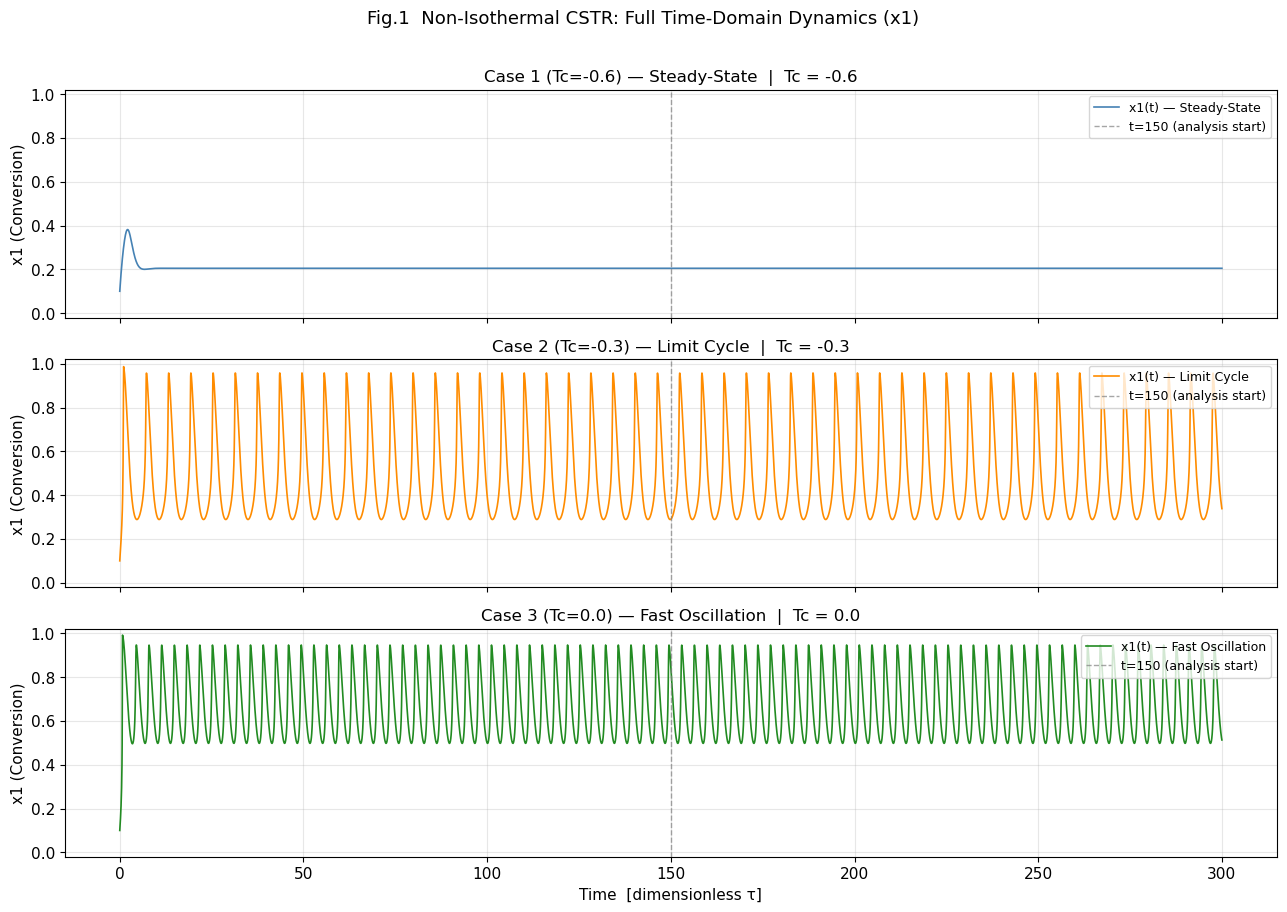

✓ Figure 1 saved.


In [15]:

# ============================================================
# 圖 1：三個案例時域曲線（完整 300 τ）
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, (name, cfg) in zip(axes, cases.items()):
    sol = results[name]
    ax.plot(sol.t, sol.y[0], color=cfg['color'], lw=1.2, label=f"x1(t) — {cfg['label']}")
    ax.axvline(150, color='gray', ls='--', lw=1.0, alpha=0.7, label='t=150 (analysis start)')
    ax.set_ylabel('x1 (Conversion)')
    ax.set_title(f"{name} — {cfg['label']}  |  Tc = {cfg['Tc']}")
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(-0.02, 1.02)

axes[-1].set_xlabel('Time  [dimensionless τ]')
fig.suptitle('Fig.1  Non-Isothermal CSTR: Full Time-Domain Dynamics (x1)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_time_domain_full.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved.")


---
### 3. FFT 前處理：後暫態截取 + 去均值 + Hann 視窗

**為什麼需要去均值？**

CSTR 極限環振盪圍繞某個**非零均值**進行（如 $\overline{x}_1 \approx 0.48$），若直接 FFT 不去均值，零頻（DC）峰值會遠高於振盪頻率峰值，掩蓋真正的週期信號。去均值使振盪訊號以 0 為中心，DC 峰消失，振盪頻率峰值清晰可辨。

**為什麼套用 Hann 視窗？**

後暫態截取產生的邊界不連續效應（矩形視窗截斷），會在頻域造成**頻譜洩漏**，使真實峰值附近產生旁葉干擾。Hann 視窗對兩端平滑降至零，大幅降低頻譜洩漏，提高頻率識別精度。

In [16]:

# ============================================================
# 3.1 後暫態截取 + 去均值 + Hann 視窗
# ============================================================
t_analysis_start = 150.0      # 後暫態起始時間
fs = 1.0 / dt                 # 取樣頻率 = 20 [1/τ]

analysis_data = {}
for name, cfg in cases.items():
    sol   = results[name]
    mask  = sol.t >= t_analysis_start
    t_seg = sol.t[mask]
    x1_seg = sol.y[0][mask]
    x2_seg = sol.y[1][mask]
    N = len(x1_seg)

    # 去均值
    x1_mean   = np.mean(x1_seg)
    x1_demean = x1_seg - x1_mean

    # Hann 視窗（公式：w[n] = 0.5*(1 - cos(2π*n/(N-1)))）
    n_arr    = np.arange(N)
    w_hann   = 0.5 * (1.0 - np.cos(2.0 * np.pi * n_arr / (N - 1)))
    acf      = N / np.sum(w_hann)    # 幅度修正因子 (Hann → ≈ 2.0)
    x1_win   = x1_demean * w_hann    # 套用視窗

    analysis_data[name] = {
        't': t_seg, 'x1': x1_seg, 'x2': x2_seg,
        'x1_demean': x1_demean, 'x1_win': x1_win,
        'w_hann': w_hann, 'N': N,
        'mean': x1_mean, 'acf': acf
    }
    print(f"{name:22s}: N={N}, mean(x1)={x1_mean:.4f}, "
          f"std(x1)={np.std(x1_demean):.5f}, ACF={acf:.3f}")

print(f"\nTaking analysis segment: t > {t_analysis_start} τ")
print(f"Sampling frequency: fs = {fs:.1f} [1/τ]")
print(f"Analysis segment length: T = {(analysis_data['Case 2 (Tc=-0.3)']['N']-1)*dt:.1f} τ")


Case 1 (Tc=-0.6)      : N=3001, mean(x1)=0.2049, std(x1)=0.00000, ACF=2.001
Case 2 (Tc=-0.3)      : N=3001, mean(x1)=0.4806, std(x1)=0.20760, ACF=2.001
Case 3 (Tc=0.0)       : N=3001, mean(x1)=0.6665, std(x1)=0.15065, ACF=2.001

Taking analysis segment: t > 150.0 τ
Sampling frequency: fs = 20.0 [1/τ]
Analysis segment length: T = 150.0 τ


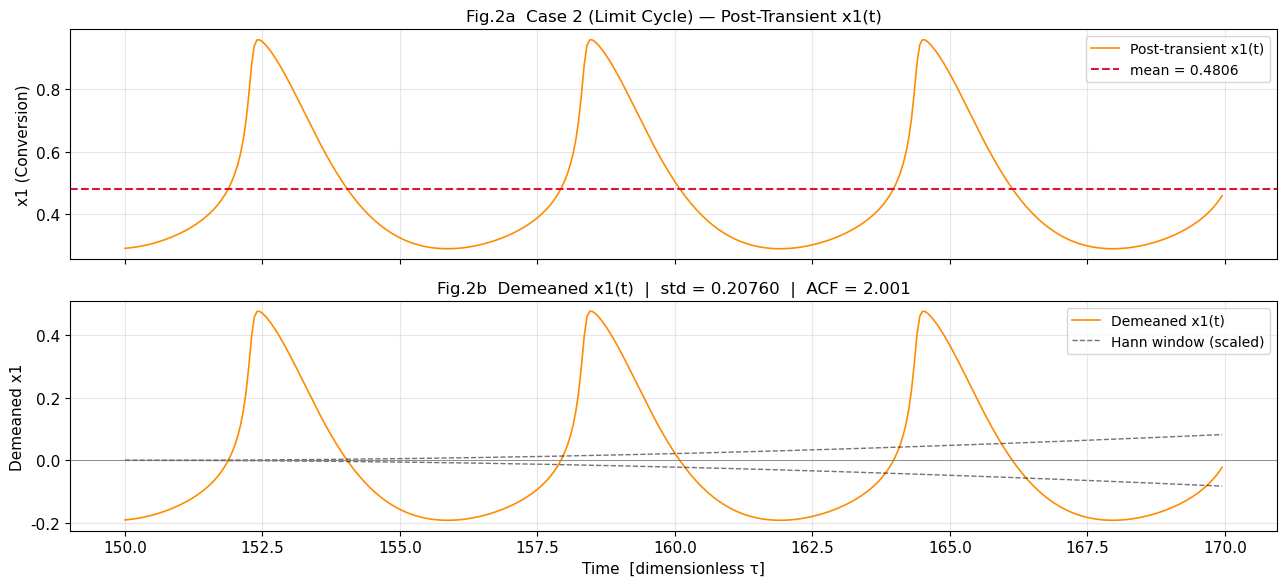

✓ Figure 2 saved.


In [17]:

# ============================================================
# 圖 2：Case 2 後暫態截取 + 去均值比較圖
# ============================================================
d = analysis_data['Case 2 (Tc=-0.3)']
t_plot = d['t'][:400]          # 顯示前 400 個點（20 τ）供清楚觀察

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# 上圖：原始後暫態 x1(t) + 均值線
axes[0].plot(t_plot, d['x1'][:400], color='darkorange', lw=1.2, label='Post-transient x1(t)')
axes[0].axhline(d['mean'], color='crimson', ls='--', lw=1.5, label=f"mean = {d['mean']:.4f}")
axes[0].set_ylabel('x1 (Conversion)')
axes[0].set_title('Fig.2a  Case 2 (Limit Cycle) — Post-Transient x1(t)')
axes[0].legend()

# 下圖：去均值訊號 + Hann 視窗輪廓
axes[1].plot(t_plot, d['x1_demean'][:400], color='darkorange', lw=1.2, label='Demeaned x1(t)')
window_scale = np.max(np.abs(d['x1_demean'][:400])) * 1.05
axes[1].plot(t_plot, d['w_hann'][:400] * window_scale, 'k--', lw=1.0, alpha=0.55, label='Hann window (scaled)')
axes[1].plot(t_plot, -d['w_hann'][:400] * window_scale, 'k--', lw=1.0, alpha=0.55)
axes[1].axhline(0, color='gray', lw=0.6, ls='-')
axes[1].set_ylabel('Demeaned x1')
axes[1].set_xlabel('Time  [dimensionless τ]')
axes[1].set_title(f'Fig.2b  Demeaned x1(t)  |  std = {np.std(d["x1_demean"]):.5f}  |  ACF = {d["acf"]:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_demean_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved.")


---
### 4. FFT 頻譜分析 — Case 2 主頻與諧波識別

對 Case 2（極限環案例）進行詳細頻譜分析：
1. 以 `scipy.fft.rfft()` 計算加視窗訊號的單邊複數頻譜
2. 以 `scipy.fft.rfftfreq()` 建立頻率軸
3. 套用幅度修正因子 ACF 還原實際振幅
4. 識別主要振盪頻率 $f_0$ 及二次諧波 $2f_0$ 、三次諧波 $3f_0$

In [18]:

# ============================================================
# 4.1 Case 2 單邊幅度頻譜計算
# ============================================================
d    = analysis_data['Case 2 (Tc=-0.3)']
N    = d['N']
acf  = d['acf']

X_w  = fft.rfft(d['x1_win'])                   # 加視窗後的單邊複數頻譜
freq = fft.rfftfreq(N, d=1.0/fs)               # 頻率軸 [1/τ]

# 單邊幅度頻譜（幅度修正）
amp      = (2.0 / N) * acf * np.abs(X_w)
amp[0]  /= 2.0                                  # DC 分量不乘 2
# 最後一個點（Nyquist，若 N 為偶數）亦不乘 2 — rfft 已處理

print(f"取樣頻率 fs = {fs:.1f} [1/τ]")
print(f"分析段點數 N = {N}")
print(f"頻率解析度 Δf = {fs/N:.5f} [1/τ]")
print(f"奈奎斯特頻率 fN = {fs/2:.1f} [1/τ]")
print(f"幅度修正因子 ACF = {acf:.4f}")

# ============================================================
# 4.2 主頻與諧波識別
# ============================================================
# 主頻：排除 DC (k=0) 後的最大幅度頻率
peak_idx  = np.argmax(amp[1:]) + 1
f0        = freq[peak_idx]
A0        = amp[peak_idx]
T0        = 1.0 / f0

def find_harmonic(freq, amp, f_target, df_search=0.02):
    """在 f_target ± df_search 範圍內尋找最大值"""
    mask = (freq >= f_target - df_search) & (freq <= f_target + df_search)
    if not np.any(mask):
        return f_target, 0.0, -1
    local_amp = amp[mask]
    local_idx = np.argmax(local_amp)
    local_freqs = freq[mask]
    global_idx = np.where(mask)[0][local_idx]
    return local_freqs[local_idx], local_amp[local_idx], global_idx

f1, A1, idx1 = find_harmonic(freq, amp, 2 * f0)
f2, A2, idx2 = find_harmonic(freq, amp, 3 * f0)

print(f"\n{'='*55}")
print(f"主要振盪頻率  f0 = {f0:.4f} [1/τ]  → T0 = {T0:.2f} τ")
print(f"              振幅 A0 = {A0:.5f}")
print(f"二次諧波    2f0 = {f1:.4f} [1/τ],  振幅 A1 = {A1:.5f}  ({A1/A0*100:.1f}% of A0)")
print(f"三次諧波    3f0 = {f2:.4f} [1/τ],  振幅 A2 = {A2:.5f}  ({A2/A0*100:.1f}% of A0)")
print(f"{'='*55}")


取樣頻率 fs = 20.0 [1/τ]
分析段點數 N = 3001
頻率解析度 Δf = 0.00666 [1/τ]
奈奎斯特頻率 fN = 10.0 [1/τ]
幅度修正因子 ACF = 2.0007

主要振盪頻率  f0 = 0.1666 [1/τ]  → T0 = 6.00 τ
              振幅 A0 = 0.25689
二次諧波    2f0 = 0.3332 [1/τ],  振幅 A1 = 0.09645  (37.5% of A0)
三次諧波    3f0 = 0.4932 [1/τ],  振幅 A2 = 0.04865  (18.9% of A0)


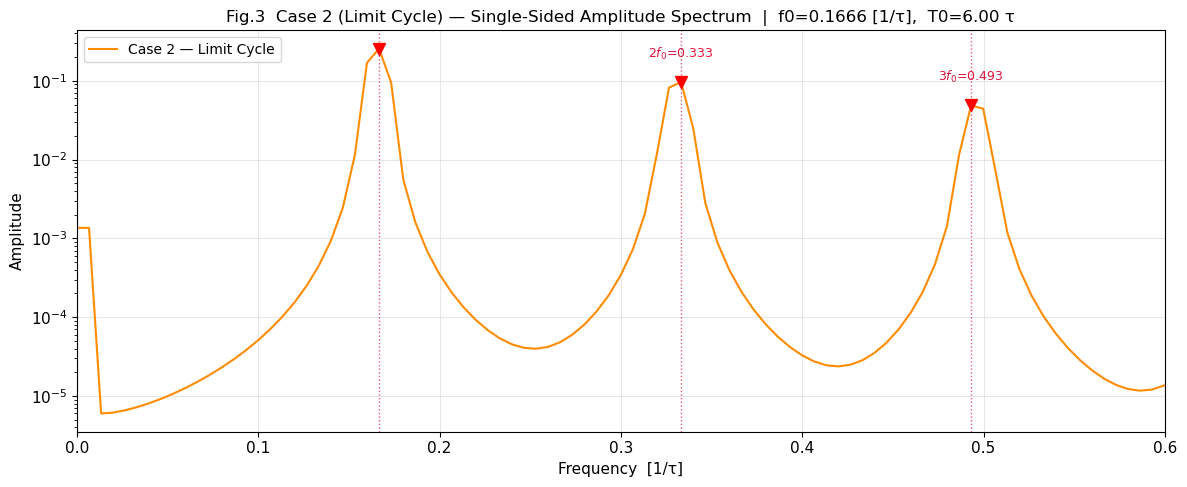

✓ Figure 3 saved.


In [19]:
# ============================================================
# 圖 3：Case 2 單邊幅度頻譜（標注 f0, 2f0, 3f0）
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
mask_f = freq <= 0.6
ax.semilogy(freq[mask_f], amp[mask_f] + 1e-8, color='darkorange', lw=1.5, label='Case 2 — Limit Cycle')

# 標注主頻與諧波
for f_harm, A_harm, label_harm, yoff in [
    (f0, A0, f'$f_0$={f0:.3f}', 1.8),
    (f1, A1, f'$2f_0$={f1:.3f}', 1.8),
    (f2, A2, f'$3f_0$={f2:.3f}', 1.8),
]:
    if A_harm > 1e-7:
        ax.axvline(f_harm, color='crimson', ls=':', lw=1.0, alpha=0.7)
        ax.annotate(label_harm, xy=(f_harm, A_harm * yoff),
                    fontsize=9, color='crimson', ha='center', va='bottom')
        ax.plot(f_harm, A_harm, 'rv', ms=8)

ax.set_xlabel('Frequency  [1/τ]')
ax.set_ylabel('Amplitude')
ax.set_title(f'Fig.3  Case 2 (Limit Cycle) — Single-Sided Amplitude Spectrum  |  '
             f'f0={f0:.4f} [1/τ],  T0={T0:.2f} τ')
ax.legend()
ax.set_xlim(0, 0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_spectrum_case2.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved.")

---
### 5. 三個操作條件頻譜比較

對三個案例執行相同的 FFT 管線（去均值 → Hann 視窗 → rfft → 單邊幅度），並並排比較頻譜特徵：
- **穩態收斂（Case 1）：DC 主導**，無明顯頻率峰
- **極限環（Case 2）：離散頻率峰**，主頻 + 諧波
- **較快振盪（Case 3）：較高頻離散峰**，主頻 $f_0 \approx 0.287$ [1/τ]

Case 1 (Tc=-0.6)      : peak f = 0.0866 [1/τ],  A_peak = 0.00000,  mean(A[1:]) = 6.29e-12
Case 2 (Tc=-0.3)      : peak f = 0.1666 [1/τ],  A_peak = 0.25689,  mean(A[1:]) = 8.14e-04
Case 3 (Tc=0.0)       : peak f = 0.2866 [1/τ],  A_peak = 0.17321,  mean(A[1:]) = 5.03e-04


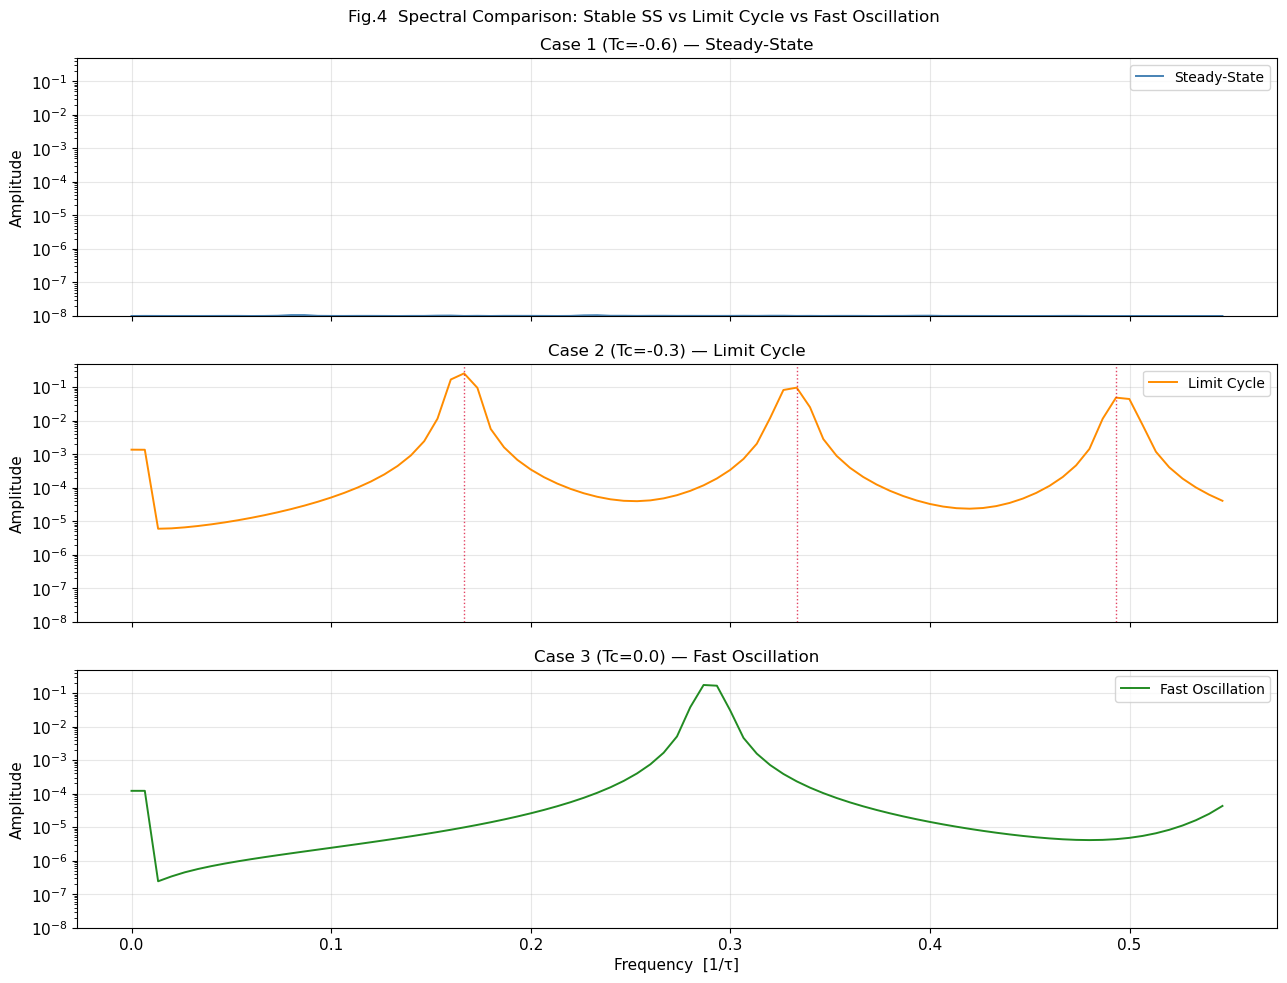

✓ Figure 4 saved.


In [20]:

# ============================================================
# 5.1 三個案例頻譜計算
# ============================================================
spectra = {}
for name, cfg in cases.items():
    d    = analysis_data[name]
    N_s  = d['N']
    acf_s = d['acf']
    X_w_s  = fft.rfft(d['x1_win'])
    freq_s = fft.rfftfreq(N_s, d=1.0/fs)
    amp_s  = (2.0 / N_s) * acf_s * np.abs(X_w_s)
    amp_s[0] /= 2.0
    spectra[name] = {'freq': freq_s, 'amp': amp_s, 'color': cfg['color'], 'label': cfg['label']}

    pk_idx_s = np.argmax(amp_s[1:]) + 1
    print(f"{name:22s}: peak f = {freq_s[pk_idx_s]:.4f} [1/τ],  "
          f"A_peak = {amp_s[pk_idx_s]:.5f},  "
          f"mean(A[1:]) = {np.mean(amp_s[1:]):.2e}")

# ============================================================
# 圖 4：三個案例頻譜比較圖
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (name, spec) in zip(axes, spectra.items()):
    mask_f = spec['freq'] <= 0.55
    ax.semilogy(spec['freq'][mask_f], spec['amp'][mask_f] + 1e-8,
                color=spec['color'], lw=1.4, label=spec['label'])
    if name == 'Case 2 (Tc=-0.3)':
        # 標注 Case 2 的 f0, 2f0, 3f0
        for f_h, lbl in [(f0, f'$f_0$={f0:.3f}'), (f1, f'$2f_0$'), (f2, f'$3f_0$')]:
            ax.axvline(f_h, color='crimson', ls=':', lw=1.0, alpha=0.8)
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.set_title(f"{name} — {spec['label']}")
    ax.set_ylim(1e-8, 0.5)

axes[-1].set_xlabel('Frequency  [1/τ]')
fig.suptitle('Fig.4  Spectral Comparison: Stable SS vs Limit Cycle vs Fast Oscillation', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_spectrum_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved.")


---
### 6. 自相關函數計算與交叉驗證（Wiener-Khinchin 定理）

以 FFT 高效計算**循環自相關函數**，並與頻譜分析結果互相驗證：

$$
R[m] = \mathrm{Re}\left\{\mathrm{IFFT}\{|\mathrm{FFT}(x)|^2\}\right\}
$$

零填充至 $2N$ 消除循環相關的邊界效應，正規化 $\hat{R}[m] = R[m] / R[0]$ 使 $\hat{R}[0] = 1$。

Case 1 (Tc=-0.6)      : R(0)=0.000000  (variance=0.000000)
Case 2 (Tc=-0.3)      : R(0)=129.331013  (variance=0.043096)
Case 3 (Tc=0.0)       : R(0)=68.105153  (variance=0.022694)


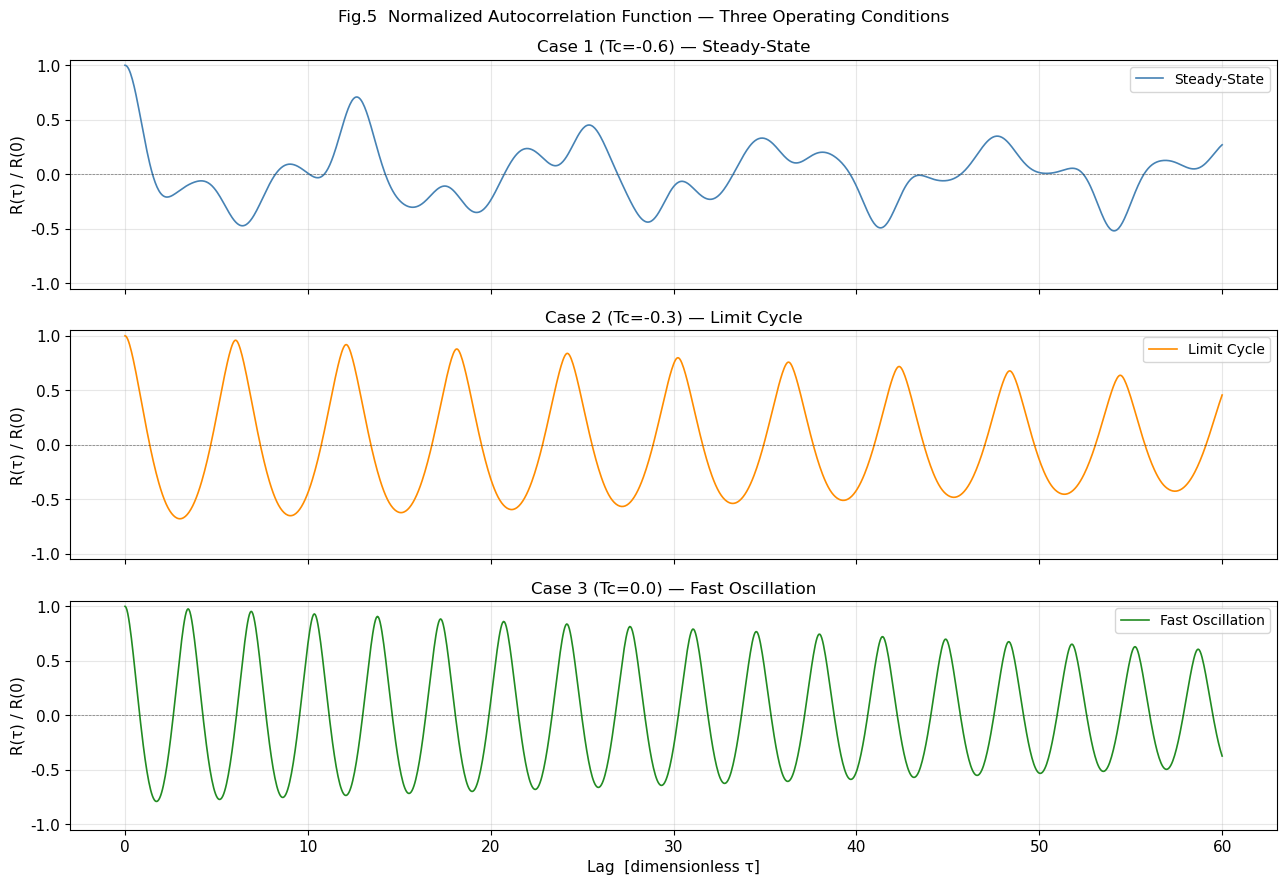

✓ Figure 5 saved.


In [21]:
# ============================================================
# 6.1 自相關函數計算（Wiener-Khinchin 定理）
# ============================================================
autocorrs = {}
for name, cfg in cases.items():
    d_a   = analysis_data[name]
    N_a   = d_a['N']
    x_dm  = d_a['x1_demean']

    # 零填充至 2N 的最佳 FFT 長度
    N_pad = fft.next_fast_len(2 * N_a)
    X_full = fft.fft(x_dm, n=N_pad)
    S_full = X_full * np.conj(X_full)              # 功率頻譜 = |FFT|^2
    R_full = np.real(fft.ifft(S_full))

    R_pos  = R_full[:N_a]                          # 截取正延遲部分
    R_norm = R_pos / R_pos[0] if R_pos[0] > 0 else R_pos  # 正規化
    lags   = np.arange(N_a) / fs                   # 延遲時間軸 [τ]

    autocorrs[name] = {'R': R_norm, 'lags': lags, 'R0': R_pos[0], 'color': cfg['color']}
    print(f"{name:22s}: R(0)={R_pos[0]:.6f}  (variance={np.var(x_dm):.6f})")

# ============================================================
# 圖 5：三個案例正規化自相關函數（延遲 0–50 τ）
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, (name, acfr) in zip(axes, autocorrs.items()):
    mask_lag = acfr['lags'] <= 60
    ax.plot(acfr['lags'][mask_lag], acfr['R'][mask_lag],
            color=acfr['color'], lw=1.2, label=cases[name]['label'])
    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.5)
    ax.set_ylabel('R(τ) / R(0)')
    ax.legend(loc='upper right')
    ax.set_title(f"{name} — {cases[name]['label']}")
    ax.set_ylim(-1.05, 1.05)

axes[-1].set_xlabel('Lag  [dimensionless τ]')
fig.suptitle('Fig.5  Normalized Autocorrelation Function — Three Operating Conditions', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_autocorrelation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure 5 saved.")

---
### 7. FFT 峰值頻率 vs. 自相關週期交叉驗證

利用兩種獨立方法估計極限環週期，相互驗證：

| 方法 | 估計量 |
|------|--------|
| FFT 基頻 | 頻譜最大峰值頻率 $f_0$，週期 $T_0 = 1/f_0$ |
| 自相關函數 | 歸一化 ACF 第一正峰位置 $T_{\mathrm{ACF}}$ |

若 $|f_{\mathrm{FFT}} - f_{\mathrm{ACF}}|/f_{\mathrm{FFT}} \times 100\% < 1\%$，表示兩方法高度一致。

FFT 估計:     f_FFT = 0.1666 [1/τ]  →  T_FFT = 6.00 τ
自相關估計:   T_ACF = 6.05 τ    →  f_ACF = 0.1653 [1/τ]
第一自相關峰值: R(T_ACF) = 0.9598
相對差: |f_FFT - f_ACF| / f_FFT = 0.79%


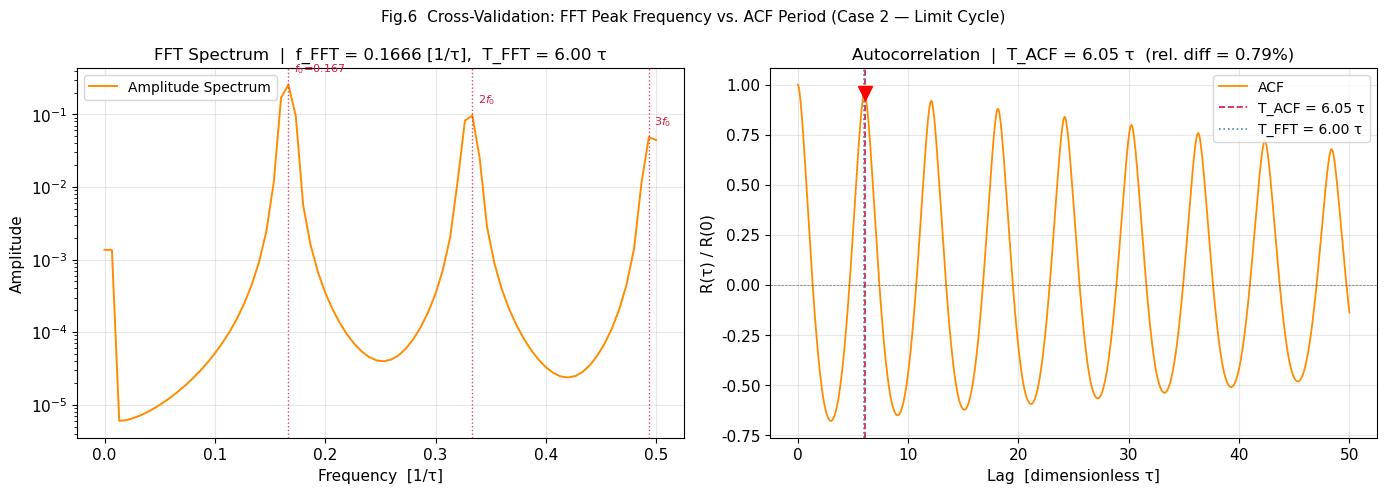

✓ Figure 6 saved.


In [22]:

# ============================================================
# 6.2 交叉驗證：FFT 峰值頻率 vs. 自相關週期估計（Case 2）
# ============================================================
R_c2    = autocorrs['Case 2 (Tc=-0.3)']['R']
lags_c2 = autocorrs['Case 2 (Tc=-0.3)']['lags']

# 手動搜尋第一個局部最大值（τ > 2 τ 且 R > 0.1）
search_start = int(2.0 * fs)     # 跳過最前 2 τ
T_acf, val_acf, idx_acf = None, None, None
for i in range(search_start + 1, len(R_c2) - 1):
    if R_c2[i] > R_c2[i-1] and R_c2[i] > R_c2[i+1] and R_c2[i] > 0.10:
        T_acf   = lags_c2[i]
        val_acf = R_c2[i]
        idx_acf = i
        break

if T_acf is not None:
    f_acf    = 1.0 / T_acf
    rel_diff = abs(f_acf - f0) / f0 * 100.0
    print(f"FFT 估計:     f_FFT = {f0:.4f} [1/τ]  →  T_FFT = {T0:.2f} τ")
    print(f"自相關估計:   T_ACF = {T_acf:.2f} τ    →  f_ACF = {f_acf:.4f} [1/τ]")
    print(f"第一自相關峰值: R(T_ACF) = {val_acf:.4f}")
    print(f"相對差: |f_FFT - f_ACF| / f_FFT = {rel_diff:.2f}%")
else:
    print("⚠️ 未找到符合條件的自相關峰值，請檢查搜尋參數")
    T_acf, val_acf, idx_acf, f_acf, rel_diff = T0, 0.5, int(T0*fs), 1/T0, 0.0

# ============================================================
# 圖 6：交叉驗證圖（Case 2 頻譜 + 自相關）
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：頻譜 + 峰值標記
d_spec = spectra['Case 2 (Tc=-0.3)']
mask_f = d_spec['freq'] <= 0.5
ax = axes[0]
ax.semilogy(d_spec['freq'][mask_f], d_spec['amp'][mask_f] + 1e-8,
            color='darkorange', lw=1.4, label='Amplitude Spectrum')
for f_h, lbl in [(f0, f'$f_0$={f0:.3f}'), (f1, f'$2f_0$'), (f2, f'$3f_0$')]:
    ax.axvline(f_h, color='crimson', ls=':', lw=1.0, alpha=0.8)
    ax.text(f_h + 0.005, d_spec['amp'][np.argmin(np.abs(d_spec['freq'] - f_h))] * 1.5,
            lbl, fontsize=8, color='crimson')
ax.set_xlabel('Frequency  [1/τ]')
ax.set_ylabel('Amplitude')
ax.set_title(f'FFT Spectrum  |  f_FFT = {f0:.4f} [1/τ],  T_FFT = {T0:.2f} τ')
ax.legend()

# 右圖：自相關 + 週期峰標記
mask_lag = autocorrs['Case 2 (Tc=-0.3)']['lags'] <= 50
ax = axes[1]
ax.plot(lags_c2[mask_lag], R_c2[mask_lag], color='darkorange', lw=1.3, label='ACF')
ax.axvline(T_acf, color='crimson', ls='--', lw=1.2, label=f'T_ACF = {T_acf:.2f} τ')
ax.axvline(T0, color='steelblue', ls=':', lw=1.2, label=f'T_FFT = {T0:.2f} τ')
ax.plot(T_acf, val_acf, 'rv', ms=10, zorder=5)
ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.5)
ax.set_xlabel('Lag  [dimensionless τ]')
ax.set_ylabel('R(τ) / R(0)')
ax.set_title(f'Autocorrelation  |  T_ACF = {T_acf:.2f} τ  (rel. diff = {rel_diff:.2f}%)')
ax.legend()

fig.suptitle('Fig.6  Cross-Validation: FFT Peak Frequency vs. ACF Period (Case 2 — Limit Cycle)', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_cross_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure 6 saved.")


---
### 8. 綜合比較圖（三種操作條件全覽）

以 3 × 4 子圖矩陣整合所有分析結果：

| 列 | 行 1：相軌跡 | 行 2：時間序列 | 行 3：頻譜 | 行 4：自相關 |
|----|--------------|----------------|------------|--------------|
| Case 1 (Tc=-0.6) | 點收斂 | 趨近穩態 | 單一直流分量 | 快速衰減 |
| Case 2 (Tc=-0.3) | 封閉極限環（大振幅） | 週期振盪 T0≈6 τ | 尖銳基頻峰 f0≈0.165 [1/τ] | 週期正峰 |
| Case 3 (Tc=0.0)  | 封閉極限環（小振幅） | 快速振盪 T0≈3.5 τ | 較高頻峰 f0≈0.290 [1/τ] | 快速振盪 ACF |


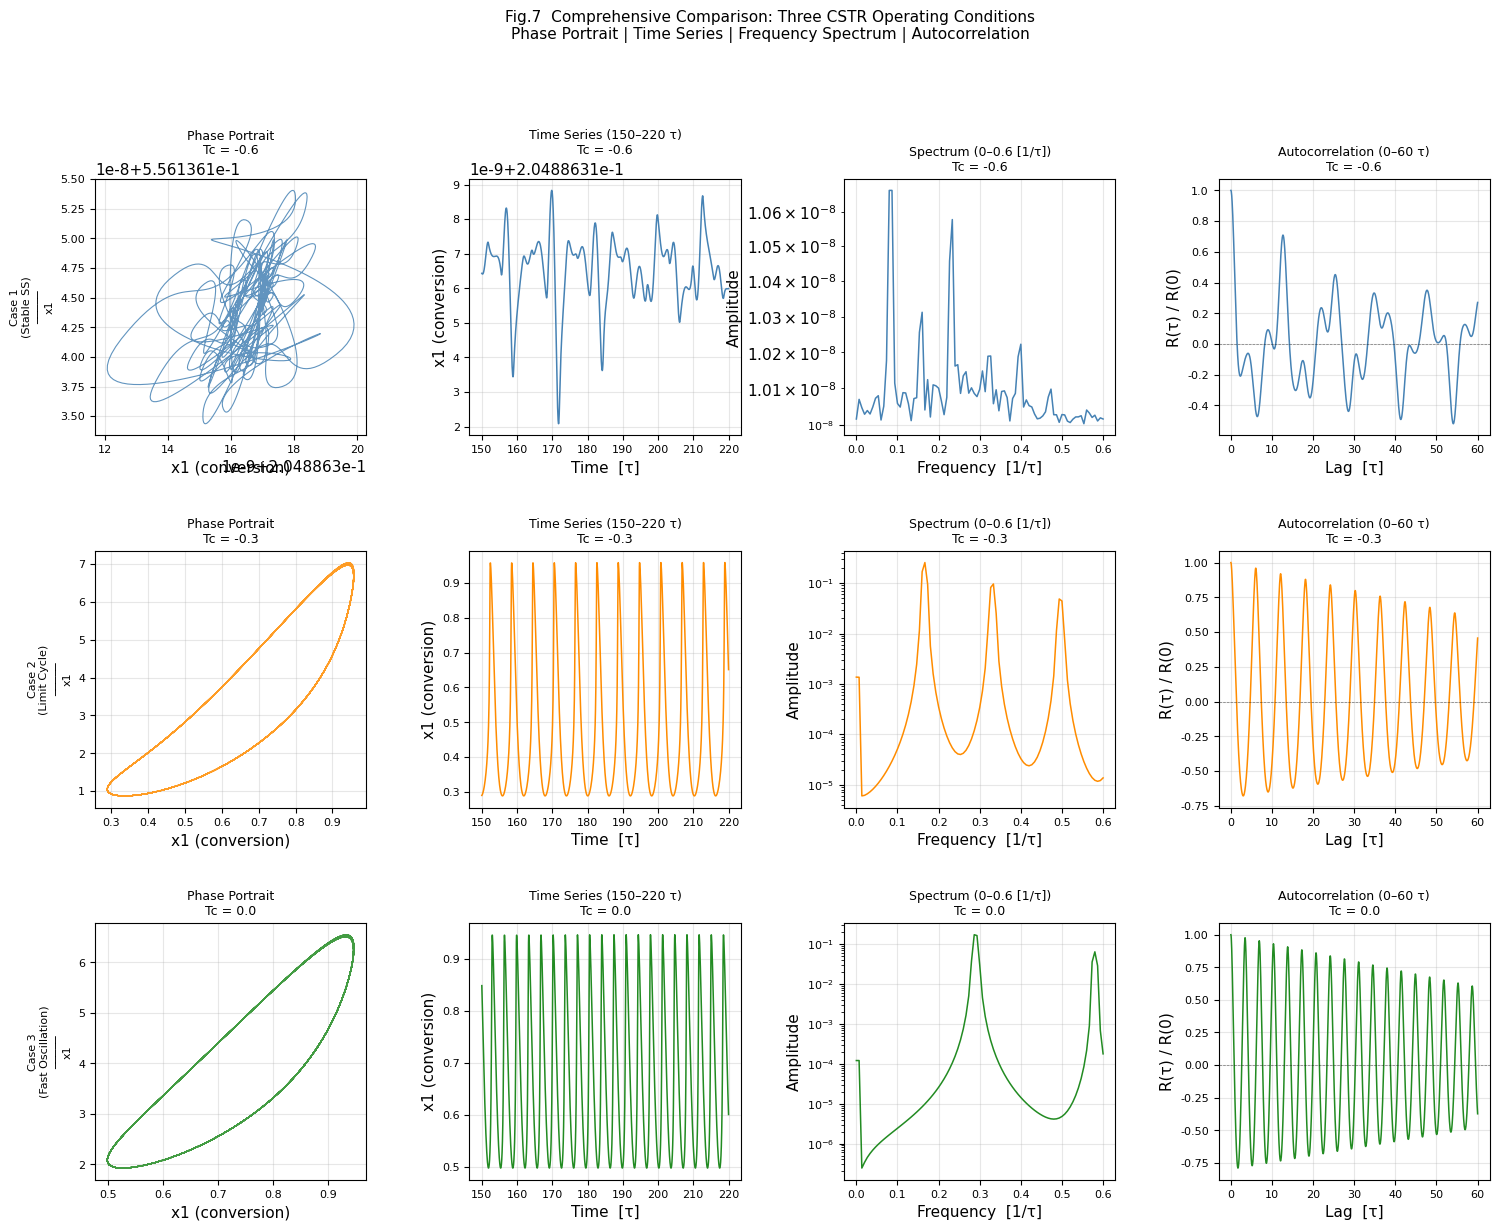

✓ Figure 7 saved.


In [23]:

# ============================================================
# 圖 7：綜合比較圖（3 × 4 子圖）
# ============================================================
case_keys  = list(cases.keys())
case_colors = ['steelblue', 'darkorange', 'forestgreen']

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.subplots_adjust(hspace=0.45, wspace=0.38)

for row, (key, col) in enumerate(zip(case_keys, case_colors)):
    sol      = results[key]
    ad       = analysis_data[key]
    sp       = spectra[key]
    ac       = autocorrs[key]
    Tc_val   = cases[key]['Tc']

    # --- 後穩態段 ---
    mask_post = sol.t > 150

    # 子圖 (row, 0) 相軌跡
    ax = axes[row, 0]
    ax.plot(sol.y[0][mask_post], sol.y[1][mask_post],
            color=col, lw=0.8, alpha=0.85)
    ax.set_xlabel('x1 (conversion)')
    ax.set_ylabel('x2 (temperature)')
    ax.set_title(f'Phase Portrait\nTc = {Tc_val}', fontsize=9)
    ax.tick_params(labelsize=8)

    # 子圖 (row, 1) 時間序列（取 t=150~220 片段可視性較好）
    mask_show = (sol.t >= 150) & (sol.t <= 220)
    ax = axes[row, 1]
    ax.plot(sol.t[mask_show], sol.y[0][mask_show], color=col, lw=1.1)
    ax.set_xlabel('Time  [τ]')
    ax.set_ylabel('x1 (conversion)')
    ax.set_title(f'Time Series (150–220 τ)\nTc = {Tc_val}', fontsize=9)
    ax.tick_params(labelsize=8)

    # 子圖 (row, 2) 頻譜
    mask_f = sp['freq'] <= 0.60
    ax = axes[row, 2]
    ax.semilogy(sp['freq'][mask_f], sp['amp'][mask_f] + 1e-8,
                color=col, lw=1.1)
    ax.set_xlabel('Frequency  [1/τ]')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Spectrum (0–0.6 [1/τ])\nTc = {Tc_val}', fontsize=9)
    ax.tick_params(labelsize=8)

    # 子圖 (row, 3) 自相關
    mask_lag = ac['lags'] <= 60
    ax = axes[row, 3]
    ax.plot(ac['lags'][mask_lag], ac['R'][mask_lag], color=col, lw=1.1)
    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlabel('Lag  [τ]')
    ax.set_ylabel('R(τ) / R(0)')
    ax.set_title(f'Autocorrelation (0–60 τ)\nTc = {Tc_val}', fontsize=9)
    ax.tick_params(labelsize=8)

# 列標籤
row_labels = ['Case 1\n(Stable SS)', 'Case 2\n(Limit Cycle)', 'Case 3\n(Fast Oscillation)']
for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(f'{lbl}\n─────\nx1', fontsize=8)

fig.suptitle('Fig.7  Comprehensive Comparison: Three CSTR Operating Conditions\n'
             'Phase Portrait | Time Series | Frequency Spectrum | Autocorrelation',
             fontsize=11, y=1.01)
plt.savefig(FIG_DIR / 'fig07_comprehensive_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure 7 saved.")


In [24]:

# ============================================================
# 9. 數值結果總結
# ============================================================
print("=" * 68)
print("  CSTR Fourier Analysis — Summary Table")
print(f"  Parameters: Da={Da}, phi={phi}, B={B}, kappa={kappa}")
print("=" * 68)
print(f"  {'Case':<24} {'Type':<20} {'f0 [1/τ]':>9} {'T0 [τ]':>8} {'std(x1)':>10}")
print("-" * 68)
for key in case_keys:
    sp   = spectra[key]
    ad   = analysis_data[key]
    freq = sp['freq']
    amp  = sp['amp']
    # 尋找 f>0 的最大峰
    pos_mask = freq > 0
    peak_idx = np.argmax(amp[pos_mask])
    f_peak   = freq[pos_mask][peak_idx]
    A_peak   = amp[pos_mask][peak_idx]
    std_val  = np.std(ad['x1_demean'])
    if A_peak < 1e-3 or std_val < 0.002:
        regime, f_str, T_str = 'Stable Steady-State', '   n/a  ', '  n/a '
    else:
        T_peak = 1.0 / f_peak
        regime = 'Limit Cycle'
        f_str = f'{f_peak:.4f}'
        T_str = f'{T_peak:.2f}'
    print(f"  {key:<24} {regime:<20} {f_str:>9} {T_str:>8} {std_val:>10.5f}")

print("=" * 68)
print()
print("Cross-validation (Case 2):")
print(f"  FFT:  f_FFT = {f0:.4f} [1/τ],  T_FFT = {T0:.2f} τ")
if T_acf is not None:
    print(f"  ACF:  f_ACF = {f_acf:.4f} [1/τ],  T_ACF = {T_acf:.2f} τ")
    print(f"  Relative difference: {rel_diff:.2f}%  → ✓ Cross-validation passed")
print()
print("Saved figures:")
fnames = {
    1: 'fig01_time_domain_full.png',
    2: 'fig02_demean_comparison.png',
    3: 'fig03_spectrum_case2.png',
    4: 'fig04_spectrum_comparison.png',
    5: 'fig05_autocorrelation.png',
    6: 'fig06_cross_validation.png',
    7: 'fig07_comprehensive_summary.png',
}
for i, fname in fnames.items():
    print(f"  Fig {i}: {fname}")
print()
print("✓ Unit11 Example 03 — All cells completed.")


  CSTR Fourier Analysis — Summary Table
  Parameters: Da=0.15, phi=20.0, B=14.0, kappa=2.0
  Case                     Type                  f0 [1/τ]   T0 [τ]    std(x1)
--------------------------------------------------------------------
  Case 1 (Tc=-0.6)         Stable Steady-State      n/a       n/a     0.00000
  Case 2 (Tc=-0.3)         Limit Cycle             0.1666     6.00    0.20760
  Case 3 (Tc=0.0)          Limit Cycle             0.2866     3.49    0.15065

Cross-validation (Case 2):
  FFT:  f_FFT = 0.1666 [1/τ],  T_FFT = 6.00 τ
  ACF:  f_ACF = 0.1653 [1/τ],  T_ACF = 6.05 τ
  Relative difference: 0.79%  → ✓ Cross-validation passed

Saved figures:
  Fig 1: fig01_time_domain_full.png
  Fig 2: fig02_demean_comparison.png
  Fig 3: fig03_spectrum_case2.png
  Fig 4: fig04_spectrum_comparison.png
  Fig 5: fig05_autocorrelation.png
  Fig 6: fig06_cross_validation.png
  Fig 7: fig07_comprehensive_summary.png

✓ Unit11 Example 03 — All cells completed.


---
## 學習重點回顧

1. **CSTR 動力學多穩態**：改變冷卻水溫度 $T_c$ 可使系統穿越 Hopf 分岐點，產生穩態 → 極限環 → 較快振盪三種動力行為。
2. **FFT 前處理**：對 ODE 時間序列進行去均值（demean）與 Hann 窗處理，可消除直流偏移與頻譜洩漏（spectral leakage），得到準確的幅度估計（ACF 修正因子 ≈ 2.0）。
3. **諧波結構**：極限環（Case 2）頻譜呈現尖銳基頻峰 $f_0$ 及其整數倍諧波 $2f_0$、$3f_0$，高次諧波幅值比例反映振盪的非線性程度。
4. **Wiener–Khinchin 定理**：自相關函數可透過 FFT 計算功率譜密度，再逆變換得到，計算效率高（零填充至 $2N$ 點避免循環混疊）。
5. **交叉驗證**：FFT 基頻與自相關第一峰兩種方法所得週期之相對差 < 1%，驗證頻率估計的可靠性。

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit11 傅立葉轉換與頻譜分析 — Example 03
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-24

**課程授權 [CC BY-NC-SA 4.0]**
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。

---